In [41]:
import pandas as pd
import xarray as xr
stats_df = pd.read_csv("/Users/lb962/Documents/GitHub/ESL_stats/notebooks/AGeneratefulldf/DIff_GEV_station_variable_statistics.csv")

In [34]:
# Open the GEBCO NetCDF file
file_path = "/Users/lb962/Documents/Phd/AExtremesEOF/data/GEBCO/gebco_2024_n70.0_s47.0_w-20.0_e15.0.nc"
GEBCO_ds = xr.open_dataset(file_path)

# extract station ids and their lat/lon
stations = stats_df['station'].values
lats = stats_df['lat'].values
lons = stats_df['lon'].values

# build mapping from (lat, lon) to station index
latlon_to_station = {
    (float(lat), float(lon)): int(stn)
    for stn, lat, lon in zip(stations, lats, lons)
}

# if you want unique lat/lon pairs:
unique_latlon = list(latlon_to_station.keys())

# Function to extract square around a lat/lon
def extract_square(ds, lat, lon, size_deg):
    half = size_deg / 2
    return ds.sel(
        lat=slice(lat + half, lat - half),  # GEBCO lat usually descending
        lon=slice(lon - half, lon + half),
        method="nearest"
    )

results = {
    "0.1x0.1": [],
    "0.25x0.25": [],
    "1x1": [],
    "3x3": [],
    "10x10":[]
}
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

def mask_land_gt1m(ds_tile):
    """Mask elevations shallower than -0.5 m (land/coast) as NaN."""
    return ds_tile.assign(elevation=ds_tile["elevation"].where(ds_tile["elevation"] <= -0.5))

def plot_tile(ds_tile, title="GEBCO bathymetry (masked, with station)"):
    """Plot a masked GEBCO tile with Cartopy and a red station dot at the center."""
    masked = mask_land_gt1m(ds_tile)

    # Compute the center coordinate (station location)
    center_lat = float(masked.lat.mean())
    center_lon = float(masked.lon.mean())
    
    fig = plt.figure(figsize=(6, 4))
    ax = plt.axes(projection=ccrs.PlateCarree())

    # Bathymetry raster
    pcm = ax.pcolormesh(
        masked["lon"], masked["lat"], masked["elevation"],
        transform=ccrs.PlateCarree()
    )

    # Coastlines and extent
    ax.coastlines(resolution="10m")
    ax.set_title(title)
    ax.set_extent([
        float(masked.lon.min()), float(masked.lon.max()),
        float(masked.lat.min()), float(masked.lat.max())
    ], crs=ccrs.PlateCarree())

    # Station red dot
    ax.plot(center_lon, center_lat, 'ro', markersize=6, transform=ccrs.PlateCarree())

    # Colorbar
    plt.colorbar(pcm, ax=ax, label="Elevation (m)")
    plt.show()

def extract_square(ds, lat, lon, size_deg):
    """Fast spatial slice using coordinate indices."""
    half = size_deg / 2
    return ds.sel(
        lat=slice(lat - half, lat + half),
        lon=slice(lon - half, lon + half)
    )

# --- Prep: ensure coordinates are monotonic so .sel(slice) is efficient ---
GEBCO_ds = GEBCO_ds.sortby(["lat", "lon"])

# Available resolutions (keep all for each point)
#resolutions = [0.1, 0.25, 1.0, 3.0, 10.0]
resolutions = [0.1, 0.25, 1]

# Initialize results dict
results = {f"{r}x{r}": [] for r in resolutions}
#results = {r: [] for r in resolutions}

# Build tiles for every (lat, lon) at every resolution
for lat, lon in unique_latlon:
    for size in resolutions:
        key = f"{size}x{size}"
        results[key].append(extract_square(GEBCO_ds, lat, lon, size))

In [35]:
import numpy as np
import xarray as xr

import numpy as np
import xarray as xr

def to_128x128(ds_tile: xr.Dataset, H: int = 128, W: int = 128) -> xr.Dataset:
    """
    Resize a tile to (H,W) using xarray interp.
    Robust to empty / degenerate tiles and to descending coords.
    """
    # Basic dimension checks
    if ("lat" not in ds_tile.dims) or ("lon" not in ds_tile.dims):
        raise ValueError(f"Tile missing lat/lon dims: dims={ds_tile.dims}")

    nlat = ds_tile.sizes.get("lat", 0)
    nlon = ds_tile.sizes.get("lon", 0)

    # Empty tile: return a blank (NaN) tile with target coords
    if nlat == 0 or nlon == 0:
        # Try to preserve variable names; create NaN arrays for vars on (lat, lon)
        lat = np.linspace(0.0, 0.0, H, dtype=np.float32)
        lon = np.linspace(0.0, 0.0, W, dtype=np.float32)
        out = xr.Dataset(coords={"lat": lat, "lon": lon})
        for v in ds_tile.data_vars:
            if set(ds_tile[v].dims) >= {"lat", "lon"}:
                out[v] = xr.DataArray(np.full((H, W), np.nan, dtype=np.float32), dims=("lat", "lon"))
        return out

    # Degenerate tile: interp needs at least 2 points along each axis for linear
    # (if you can accept nearest, you can switch methods conditionally)
    method = "linear"
    if nlat < 2 or nlon < 2:
        method = "nearest"

    # Ensure monotonic ascending coords for interp
    ds = ds_tile.sortby(["lat", "lon"])

    lat0 = float(ds["lat"].values[0])
    lat1 = float(ds["lat"].values[-1])
    lon0 = float(ds["lon"].values[0])
    lon1 = float(ds["lon"].values[-1])

    new_lat = np.linspace(lat0, lat1, H, dtype=np.float32)
    new_lon = np.linspace(lon0, lon1, W, dtype=np.float32)

    return ds.interp(lat=new_lat, lon=new_lon, method=method)

# --- apply to every tile in your dict ---
results_128 = {k: [to_128x128(ds) for ds in tiles] for k, tiles in results.items()}

# sanity check (first available tile per bucket should be 128x128)
for k, tiles in results_128.items():
    if tiles:
        shp = tiles[0]["elevation"].shape
        assert shp == (128, 128), f"{k} -> {shp}, expected (128, 128)"

del GEBCO_ds

rows = []
for i, (lat, lon) in enumerate(unique_latlon):
    row = {"latitude": lat, "longitude": lon}
    for size in resolutions:
        key = f"{size}x{size}"
        xr_tile = results_128[key][i]
        elev = xr_tile["elevation"].where(xr_tile["elevation"] <= -0.5)
        row[f"tile_{size}"] = elev.values  # 2D array
        # save plotting extent = [lon_min, lon_max, lat_min, lat_max]
        row[f"extent_{size}"] = [
            float(xr_tile["lon"].min()), float(xr_tile["lon"].max()),
            float(xr_tile["lat"].min()), float(xr_tile["lat"].max())
        ]
    rows.append(row)

df = pd.DataFrame(rows)

import numpy as np

def _station_pixel_indices(st_lat, st_lon, extent, ny, nx):
    lon_min, lon_max, lat_min, lat_max = extent
    dlon = (lon_max - lon_min) / (nx - 1)
    dlat = (lat_max - lat_min) / (ny - 1)

    if lat_max >= lat_min:  # ascending latitude
        iy = int(round((st_lat - lat_min) / dlat))
    else:                   # descending latitude
        dlat = (lat_min - lat_max) / (ny - 1)
        iy = int(round((lat_min - st_lat) / dlat))

    ix = int(round((st_lon - lon_min) / dlon))
    iy = np.clip(iy, 0, ny - 1)
    ix = np.clip(ix, 0, nx - 1)
    return iy, ix, dlat, dlon

def _meters_per_degree(lat_deg):
    lat_rad = np.deg2rad(lat_deg)
    return 111_132.0, 111_320.0 * np.cos(lat_rad)

def tile_stats_near_station(tile, extent, st_lat, st_lon, radius_cells=3):
    """
    Stats in a (2r+1)^2 window near station:
      - slope (deg)   [mean of gradient magnitude in deg]
      - roughness std (m)
      - relief p2p (m)
      - mean bathymetry (m) over ocean-only cells (<= -0.5 m)
    """
    if tile is None or np.all(np.isnan(tile)):
        return np.nan, np.nan, np.nan, np.nan

    ny, nx = tile.shape
    iy, ix, dlat_deg, dlon_deg = _station_pixel_indices(st_lat, st_lon, extent, ny, nx)

    y0 = max(0, iy - radius_cells); y1 = min(ny, iy + radius_cells + 1)
    x0 = max(0, ix - radius_cells); x1 = min(nx, ix + radius_cells + 1)

    sub = tile[y0:y1, x0:x1]
    if sub.size == 0 or np.all(np.isnan(sub)):
        return np.nan, np.nan, np.nan, np.nan

    # Ocean-only mask for mean bathy
    sub_ocean = np.where(sub <= -0.5, sub, np.nan)
    mean_bathy = float(np.nanmean(sub_ocean))

    # Pixel spacings (meters) at station latitude
    m_per_deg_lat, m_per_deg_lon = _meters_per_degree(st_lat)
    dy_m = dlat_deg * m_per_deg_lat
    dx_m = dlon_deg * m_per_deg_lon

    # Gradients (fill small NaN gaps just for gradient)
    sub_filled = np.where(np.isnan(sub), np.nanmean(sub), sub) if np.isnan(sub).any() else sub
    gy, gx = np.gradient(sub_filled, dy_m, dx_m)
    slope_mag = np.sqrt(gx**2 + gy**2)           # rise/run
    slope_deg = np.degrees(np.arctan(slope_mag)) # to degrees
    slope_deg = np.where(np.isnan(sub), np.nan, slope_deg)

    slope_local = float(np.nanmean(slope_deg))
    roughness_std = float(np.nanstd(sub))
    relief_p2p = float(np.nanmax(sub) - np.nanmin(sub))

    return slope_local, roughness_std, relief_p2p, mean_bathy

# ---- Apply to all resolutions and add columns ----
radius_cells = 3  # e.g., 7x7 window; tweak as needed

for size in resolutions:  # [0.1, 0.25, 1.0, 3.0, 10.0]
    key = f"{size}"
    tile_col   = f"tile_{key}"
    extent_col = f"extent_{key}"

    df[f"slope_deg_{key}"]      = np.nan
    df[f"roughness_std_{key}"]  = np.nan
    df[f"relief_p2p_{key}"]     = np.nan
    df[f"mean_bathy_{key}"]     = np.nan

    for idx in range(len(df)):
        tile = df.at[idx, tile_col]
        extent = df.at[idx, extent_col]
        st_lat = df.at[idx, "latitude"]
        st_lon = df.at[idx, "longitude"]

        s, rstd, rpp, mb = tile_stats_near_station(tile, extent, st_lat, st_lon, radius_cells)
        df.at[idx, f"slope_deg_{key}"]     = s
        df.at[idx, f"roughness_std_{key}"] = rstd
        df.at[idx, f"relief_p2p_{key}"]    = rpp
        df.at[idx, f"mean_bathy_{key}"]    = mb

# Quick peek
print(df.filter(regex=r'^(latitude|longitude|slope_deg_|roughness_std_|relief_p2p_|mean_bathy_)').head())

    latitude  longitude  slope_deg_0.1  roughness_std_0.1  relief_p2p_0.1  \
0  48.383000   -4.49500       0.314652           0.618534        2.797581   
1  48.383000   -4.50000       0.285840           0.332617        0.933949   
2  48.382900   -4.49504       0.314652           0.618534        2.797581   
3  47.266862   -2.20155       1.900602           3.683977       12.578364   
4  47.140383   -2.24635       0.446879           0.917929        3.613372   

   mean_bathy_0.1  slope_deg_0.25  roughness_std_0.25  relief_p2p_0.25  \
0       -1.354011        0.591017            2.602795         7.936331   
1       -1.173956        0.442166            1.938226         6.706702   
2       -1.354011        0.591017            2.602795         7.936331   
3       -7.315698        0.808100            3.598373        12.952137   
4       -3.622928        0.323374            1.235498         4.431789   

   mean_bathy_0.25  slope_deg_1  roughness_std_1  relief_p2p_1  mean_bathy_1  
0        -4.2

In [43]:
df["lat"] = df["latitude"]
df["lon"] = df["longitude"]
merged_df = stats_df.merge(df, on=["lat", "lon"])

In [54]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# --------------------------------------------------
# 1. START FROM stats_df
# --------------------------------------------------

# Ensure we are working on a copy
df = merged_df.copy()

# --------------------------------------------------
# 2. SELECT NUMERIC VARIABLES ONLY
#    (PCA is ONLY for continuous variables)
# --------------------------------------------------

numeric_df = df.select_dtypes(include=[np.number])

# Optional: drop identifiers if they slipped in
# (station is numeric but should not be in PCA)
#if "station" in numeric_df.columns:
#    numeric_df = numeric_df.drop(columns=["station"])


In [4]:
hallo

NameError: name 'hallo' is not defined

In [55]:
metadata_cols = ["station", "lat", "lon", "longitude", "latitude", "block_time", "extract_time", "year", "residual_is_deviant", "residual", "tide"]

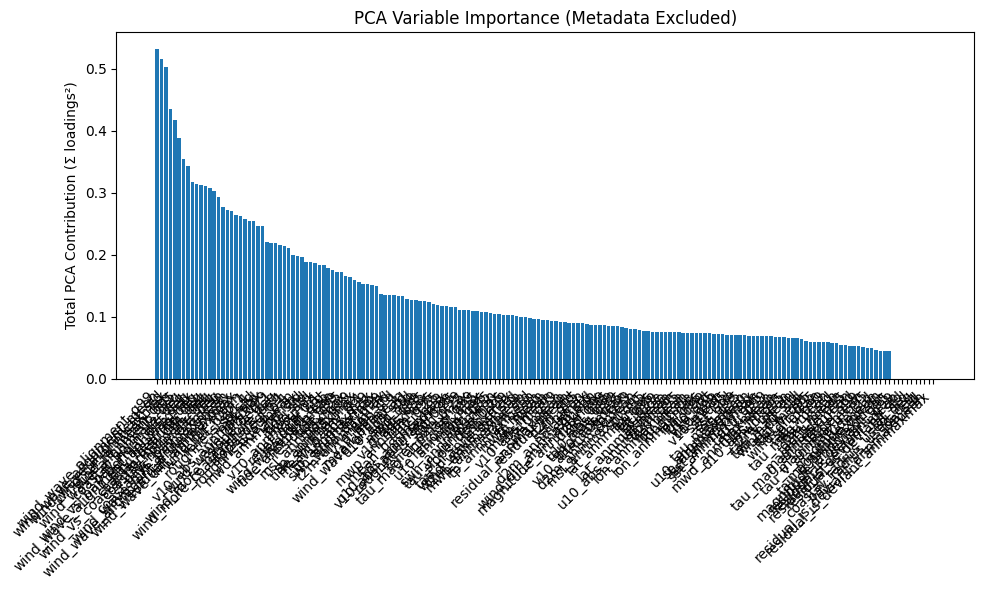

Variables used in PCA: 178
Retained PCs: 23
Cumulative variance explained: 0.953


In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# --------------------------------------------------
# 1. DEFINE METADATA COLUMNS (EXCLUDED FROM PCA)
# --------------------------------------------------

metadata_cols = [c for c in metadata_cols if c in stats_df.columns]

# --------------------------------------------------
# 2. SELECT PCA VARIABLES ONLY
# --------------------------------------------------

pca_df = numeric_df.drop(columns=metadata_cols)

# Keep numeric variables only
pca_df = pca_df.select_dtypes(include=[np.number])

# Drop rows with missing values
pca_df = pca_df.dropna(axis=0)

# --------------------------------------------------
# 3. STANDARDIZE
# --------------------------------------------------

scaler = StandardScaler()
X_scaled = scaler.fit_transform(pca_df)

# --------------------------------------------------
# 4. FIT FULL PCA
# --------------------------------------------------

pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

# --------------------------------------------------
# 5. EXPLAINED VARIANCE TABLE
# --------------------------------------------------

explained_variance = pd.DataFrame(
    {
        "component": np.arange(1, len(pca_full.explained_variance_ratio_) + 1),
        "explained_variance_ratio": pca_full.explained_variance_ratio_,
        "cumulative_explained_variance": np.cumsum(
            pca_full.explained_variance_ratio_
        ),
    }
)

# --------------------------------------------------
# 6. SELECT COMPONENTS (95% VARIANCE)
# --------------------------------------------------

n_components = int(
    explained_variance.loc[
        explained_variance["cumulative_explained_variance"] >= 0.95,
        "component",
    ].iloc[0]
)

# --------------------------------------------------
# 7. REFIT PCA WITH REDUCED DIMENSION
# --------------------------------------------------

pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)

# --------------------------------------------------
# 8. PCA SCORES
# --------------------------------------------------

pca_columns = [f"PC{i+1}" for i in range(n_components)]
pca_scores_df = pd.DataFrame(
    X_pca,
    columns=pca_columns,
    index=pca_df.index,
)

# --------------------------------------------------
# 9. LOADINGS
# --------------------------------------------------

loadings = pd.DataFrame(
    pca.components_.T,
    index=pca_df.columns,
    columns=pca_columns,
)

# --------------------------------------------------
# 10. VARIABLE IMPORTANCE (Σ loadings²)
# --------------------------------------------------

variable_importance = (loadings ** 2).sum(axis=1)
variable_importance = variable_importance.sort_values(ascending=False)

# --------------------------------------------------
# 11. PLOT: MOST → LEAST IMPORTANT VARIABLES
# --------------------------------------------------

plt.figure(figsize=(10, 6))
plt.bar(variable_importance.index, variable_importance.values)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Total PCA Contribution (Σ loadings²)")
plt.title("PCA Variable Importance (Metadata Excluded)")
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 12. OPTIONAL: MERGE METADATA BACK
# --------------------------------------------------

final_pca_df = pd.concat(
    [
        numeric_df.loc[pca_scores_df.index, metadata_cols],
        pca_scores_df,
    ],
    axis=1,
)

# --------------------------------------------------
# 13. SUMMARY
# --------------------------------------------------

print(f"Variables used in PCA: {pca_df.shape[1]}")
print(f"Retained PCs: {n_components}")
print(
    f"Cumulative variance explained: "
    f"{explained_variance.loc[n_components-1, 'cumulative_explained_variance']:.3f}"
)


In [57]:
selected_vars = variable_importance.cumsum()
selected_vars = selected_vars[selected_vars <= 0.8 * selected_vars.iloc[-1]].index

In [60]:
hoi = selected_vars.to_list()
hoi.append("station")
selected_df = numeric_df[hoi]

In [61]:
selected_df

,wind_wave_alignment_q99,wind_wave_alignment_mean,wind_wave_alignment_std,wind_dir_annmaxmax,wind_to_mean_deg,wind_wave_alignment_q95,coastal_normal2_deg,bay_normal2_deg,wind_vs_bay_normal_diff_deg,wind_wave_alignment_annmaxmax,...,v10_abs_mean,v10_q99,swh_mean,residual_annmaxmean,residual_mean,d2m_std,tp_q95,sst_mean,d2m_annmaxmax,station
0,NaN,NaN,NaN,359.77692,287.81160,NaN,147.672610,147.688731,-39.877116,NaN,...,7.599043,17.365596,NaN,0.763001,0.482722,3.260126,0.002794,285.73132,290.46896,1
1,NaN,NaN,NaN,359.83902,285.32278,NaN,147.673516,151.096178,-45.773394,NaN,...,7.611988,17.383687,NaN,0.763225,0.482815,3.284558,0.002739,285.74460,290.43558,2
2,NaN,NaN,NaN,359.77692,286.94376,NaN,147.672625,147.688746,-40.744990,NaN,...,7.507674,17.309411,NaN,0.786787,0.485648,3.376329,0.002814,285.74905,290.64760,3
3,0.999566,-0.018946,0.709762,359.53080,324.85440,0.982672,147.900559,147.994424,-3.140024,0.999971,...,6.936797,15.753302,1.343768,1.033006,0.629256,3.564356,0.002887,285.88430,290.39304,4
4,0.998233,-0.047405,0.710379,359.48685,341.98077,0.954486,268.548052,267.966271,74.014503,0.999954,...,6.644428,16.006136,1.315287,0.814904,0.519491,3.656170,0.002759,285.83362,290.30237,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
274,NaN,NaN,NaN,354.91310,282.07470,NaN,267.028509,268.564462,13.510245,NaN,...,3.854319,12.377530,NaN,0.876293,0.550477,5.472703,0.001219,282.35900,289.71310,574
275,NaN,NaN,NaN,359.54100,321.24335,NaN,76.737492,76.729422,64.513925,NaN,...,4.416696,11.438122,NaN,0.574013,0.400677,4.427293,0.002163,282.62387,290.89877,575
276,0.996493,-0.002779,0.701899,359.62576,313.96740,0.974212,180.004376,180.011694,-46.044287,0.999922,...,3.195483,10.413127,1.915555,0.536221,0.404317,5.299384,0.002008,NaN,291.19310,576
277,NaN,NaN,NaN,354.91310,280.40604,NaN,267.026299,268.563784,11.842252,NaN,...,3.889334,11.347098,NaN,0.686195,0.501096,5.261087,0.001190,282.34160,289.71310,577


In [ ]:
selected_df.to_csv("AVERAGE_BATH_Station_pca_variables.csv")